The dataset `votes_repub` contains information on the percentage of votes cast for Republicans in the U.S. presidential elections from 1856 to 1976. Using the Manhattan distance as a measure of dissimilarity and the complete linkage method, perform hierarchical clustering on this dataset. Draw a dendrogram. Which number of clusters seems most sensible? Then, in the layout of the first two principal components, visualize the results (points corresponding to different states should have the same color if they belong to the same cluster). Try to add the names of the states to the plot.

S. Peterson (1973): A Statistical History of the American Presidential Elections. New York: Frederick Ungar Publishing Co.

<class 'pandas.DataFrame'>
Index: 19 entries, California to Wisconsin
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1856   19 non-null     float64
 1   X1860   19 non-null     float64
 2   X1864   19 non-null     float64
 3   X1868   19 non-null     float64
 4   X1872   19 non-null     float64
 5   X1876   19 non-null     float64
 6   X1880   19 non-null     float64
 7   X1884   19 non-null     float64
 8   X1888   19 non-null     float64
 9   X1892   19 non-null     float64
 10  X1896   19 non-null     float64
 11  X1900   19 non-null     float64
 12  X1904   19 non-null     float64
 13  X1908   19 non-null     float64
 14  X1912   19 non-null     float64
 15  X1916   19 non-null     float64
 16  X1920   19 non-null     float64
 17  X1924   19 non-null     float64
 18  X1928   19 non-null     float64
 19  X1932   19 non-null     float64
 20  X1936   19 non-null     float64
 21  X1940   19 non-null     float64
 22  X194

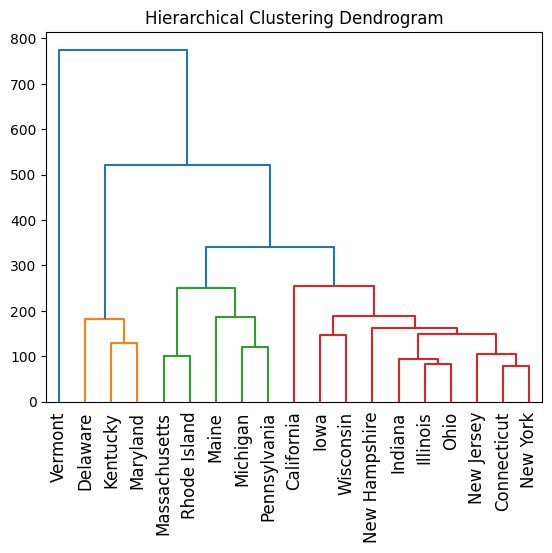

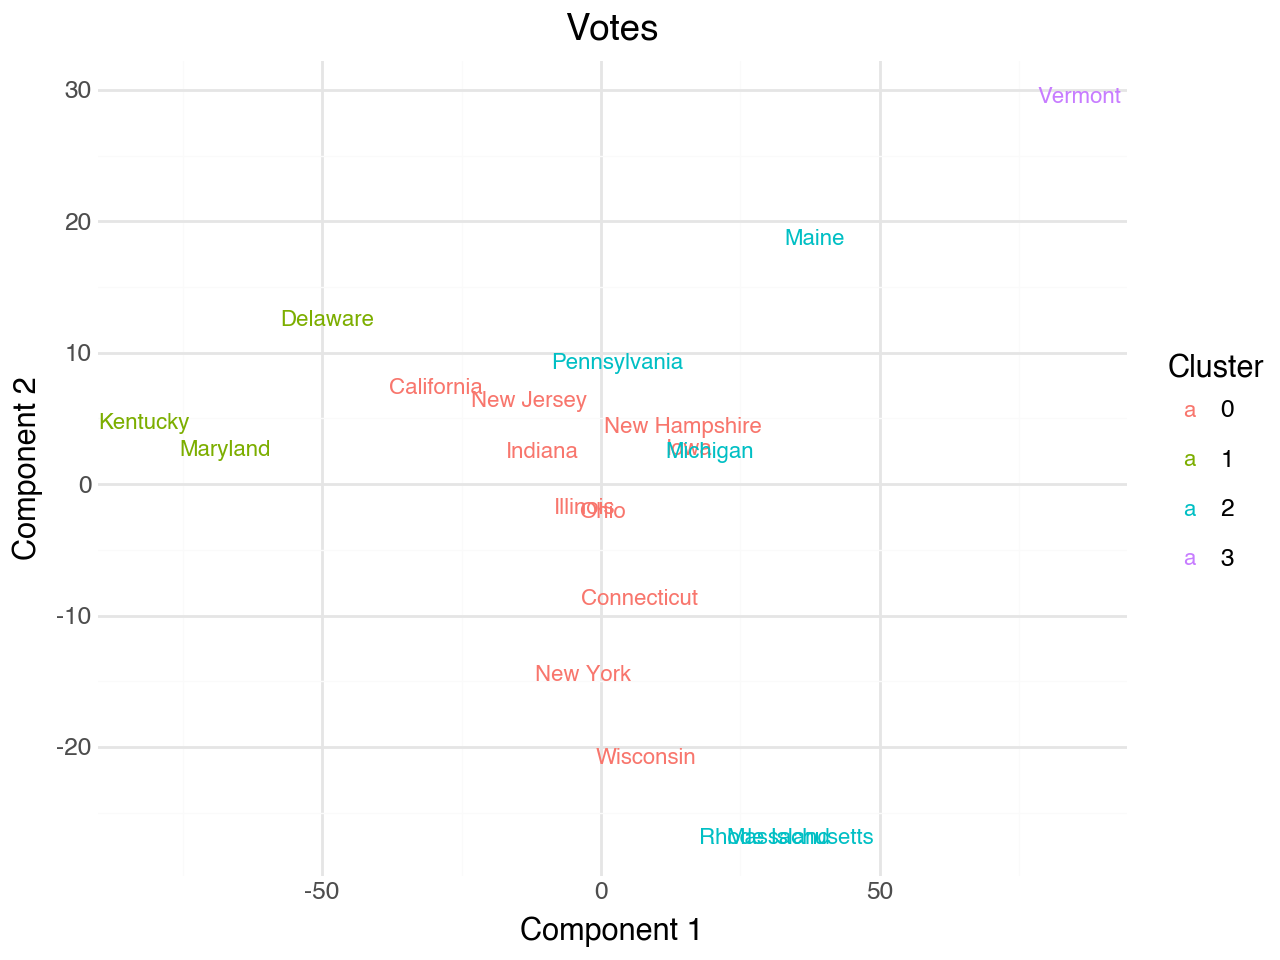

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from plotnine import ggplot, aes, geom_text, labs, theme_minimal, guides, guide_legend
df = pd.read_csv('../data/votes_repub.csv', index_col=0)
df.head()
df.info()
# Hierarchical clustering
clusters = linkage(
    pdist(
        df,
        metric = 'cityblock'
    ),
    method = 'complete'
)

dendrogram(
    clusters,
    labels = df.index,
    color_threshold = 300
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xticks(rotation=90)
plt.show()
# PCA
pca = PCA()
components = pca.fit_transform(df)
df_results = pd.DataFrame(components).iloc[:, [0, 1]]
df_results.rename(
    columns = {
        0: 'PC1',
        1: 'PC2'
    },
    inplace = True
)
# Cut tree
df_results['Cluster'] = cut_tree(
    clusters,
    n_clusters = 4
).reshape(-1, )
df_results['State'] = df.index
df_results.head()
(
    ggplot(
        df_results,
        aes(
            x = 'PC1',
            y = 'PC2',
            color = 'factor(Cluster)',
            label = 'State'
        )
    )
    +geom_text(size = 8)
    +labs(
        title = 'Votes',
        x = 'Component 1',
        y = 'Component 2'
    )
    +guides(color = guide_legend(title = 'Cluster'))
    +theme_minimal()
)